In [1]:
%load_ext autoreload
%autoreload 2
%config Completer.use_jedi = False

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import yaml, pickle, glob, csv

In [3]:
import sys
sys.path.append('./code')

In [4]:
from models import XASGNN, SpectrumHead, XASLightningModule, MLPLightningModule
from data import XASGraphDataset, FeatureDataset, collate_fn

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import lightning.pytorch as pl
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping, TQDMProgressBar     

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
GRID=np.linspace(9500-600, 9650-600, 1000)
energy_grid = GRID[333:733:2]
ROOT_PATH = './'

In [8]:
with open(ROOT_PATH + "/configs/config.yaml", "r") as f:
    config = yaml.safe_load(f)

## 1. Load data

In [9]:
train_structures = pickle.load(open(ROOT_PATH + '/dataset/train_structures.pkl', 'rb'))
train_spectra = torch.load(ROOT_PATH + "/dataset/train_spectra.pt")
val_structures = pickle.load(open(ROOT_PATH + '/dataset/val_structures.pkl', 'rb'))
val_spectra = torch.load(ROOT_PATH + "/dataset/val_spectra.pt")
# test_structures = pickle.load(open(ROOT_PATH + '/dataset/test_structures.pkl', 'rb'))
# test_spectra = torch.load(ROOT_PATH + "/dataset/test_spectra.pt")

In [10]:
cutoff = config['gnn']['cutoff']

In [11]:
train_dataset = XASGraphDataset(train_structures, train_spectra, cutoff=cutoff)
val_dataset = XASGraphDataset(val_structures, val_spectra, cutoff=cutoff)
# test_dataset = XASGraphDataset(test_structures, test_spectra, cutoff=cutoff)

/hpcgpfs01/scratch/ccao/GNN-XAS-ZnCl2aq/./code/data.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.spectra.append(torch.tensor(spec, dtype=torch.float32))


In [12]:
train_loader = DataLoader(train_dataset, batch_size=config['training']['batch_size'], shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config['training']['batch_size'], collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=config['training']['batch_size'], collate_fn=collate_fn)

## 2. Train model

### 2.1. Train GNN model

#### 2.1.1. Train

In [13]:
csv_logger = CSVLogger("lightning_logs", name="gnn-%s-%s"%(config['gnn']['cutoff'],config['gnn']['nblocks']))
early_stop_callback = EarlyStopping(
    monitor='val_loss',     # Metric to monitor
    min_delta=1e-5,       
    patience=20,          
    mode='min'             
)

In [14]:
gnn_config = dict(
    nblocks = config['gnn']['nblocks'], 
    cutoff = config['gnn']['cutoff'], 
    threebody_cutoff = config['gnn']['threebody_cutoff']
)

head_config = dict(
    hidden_dims = [64, 64], 
    output_size = config['head']['output_size'], 
    drop_rate = config['head']['drop_rate'], 
)

In [15]:
model = XASLightningModule(gnn_config, head_config, learning_rate=config['training']['lr'])

In [16]:
#### Modify max_epochs here ### 
trainer = pl.Trainer(max_epochs=10, accelerator="gpu", devices=1, 
                     callbacks=[early_stop_callback, 
                                TQDMProgressBar(refresh_rate=0), 
                                pl.callbacks.ModelCheckpoint(monitor='val_loss', save_top_k=1)
                               ], 
                     log_every_n_steps=0,          # disables step-level logging
                     logger=csv_logger,                     
                    )
trainer.fit(model, train_loader, val_loader)

# torch.save(model.state_dict(), "./trained-models/xas_lightning_model.pth")  

/hpcgpfs01/scratch/ccao/envs/ml-xas/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /hpcgpfs01/scratch/ccao/envs/ml-xas/lib/python3.10/s ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type         | Params | Mode 
-------------------------------------------------------
0 | loss_fn       | 

#### 2.1.2. Predict 

In [17]:
loadpath = './lightning_logs/gnn-4.0-3/version_0/'
model = XASLightningModule.load_from_checkpoint(glob.glob(loadpath+'checkpoints/*.ckpt')[0])

In [18]:
model = model.to(device)
model.eval()

predictions = []
val_loss = 0.0

with torch.no_grad():   # disables gradient tracking
    for g, _, spectra in val_loader:
        g, spectra = g.to(device), spectra.to(device)
        y_hat = model(g)

        predictions.append(y_hat.cpu())

        loss = torch. nn.MSELoss()(y_hat, spectra)
        val_loss += loss.item() * spectra.size(0)  # sum over batch

# concatenate all predictions into one tensor
predictions = torch.cat(predictions, dim=0)

print(f"Validation loss: {val_loss / len(val_loader.dataset)}")

Validation loss: 0.007854002829066557


#### 2.1.3 Plot learning curve

In [19]:
metrics = []
with open(loadpath + '/metrics.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        metrics.append(row)

In [20]:
epochs = []
val_losses = []
train_losses = []
for row in metrics:
    if row["val_loss"]:  # not empty
        epochs.append(int(row["epoch"]))
        val_losses.append(float(row["val_loss"]))
    if row["train_loss"]:  # not empty
        train_losses.append(float(row["train_loss"]))    

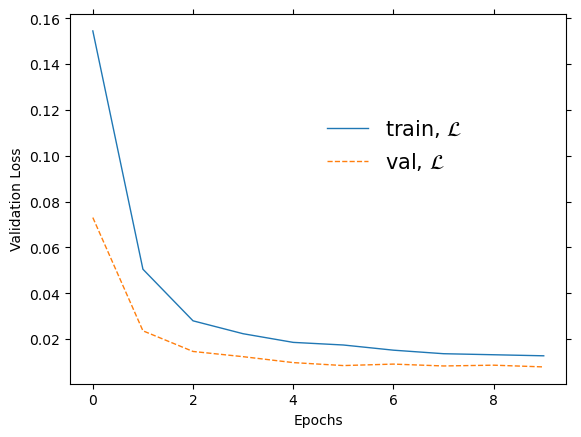

In [21]:
plt.plot(epochs, train_losses, lw=1, label='train, $\mathcal{L}$')
plt.plot(epochs, val_losses, lw=1, linestyle='--', label='val, $\mathcal{L}$')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.tick_params(bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=15, frameon=False, loc=(0.5, 0.55))
# plt.yscale('log')  # Set the y-axis to a logarithmic scale
# plt.savefig('./figures/loss_curve.png', bbox_inches='tight', dpi=250)

### 2.2. Train MLP model

#### 2.2.1 Load pre-trained gnn and featurize

In [22]:
def cache_features(gnn, dataloader, save_path="absorber_features.pt", device="cuda"):
    gnn.eval().to(device)
    feats_all, spectra_all = [], []

    with torch.no_grad():
        for g, _, spectra in dataloader:
            g = g.to(device)
            spectra = spectra.to(device)
            feats = gnn(g)  # (B, d)
            feats_all.append(feats.cpu())
            spectra_all.append(spectra.cpu())

    feats_all = torch.cat(feats_all, dim=0)
    spectra_all = torch.cat(spectra_all, dim=0)
    torch.save((feats_all, spectra_all), save_path)
    print(f"Saved cached features to {save_path}")

In [23]:
loadpath = './lightning_logs/gnn-4.0-3/version_0/'
model = XASLightningModule.load_from_checkpoint(glob.glob(loadpath+'checkpoints/*.ckpt')[0])

In [24]:
# Save to cached features
features_file = "absorber_features.pt"
cache_features(model.gnn, train_loader, save_path=loadpath+"/train_" + features_file, device=device)
cache_features(model.gnn, val_loader, save_path=loadpath+"/val_" + features_file, device=device)

Saved cached features to ./lightning_logs/gnn-4.0-3/version_0//train_absorber_features.pt
Saved cached features to ./lightning_logs/gnn-4.0-3/version_0//val_absorber_features.pt


In [25]:
# Load cached features
features_file = "absorber_features.pt"

train_feats, train_spectra = torch.load(loadpath+"/train_" + features_file)
val_feats, val_spectra = torch.load(loadpath+"/val_" + features_file)

train_dataset_feat = FeatureDataset(train_feats, train_spectra)
val_dataset_feat = FeatureDataset(val_feats, val_spectra)

train_loader_feat = DataLoader(train_dataset_feat, batch_size=config['training']['batch_size'], shuffle=True)
val_loader_feat = DataLoader(val_dataset_feat, batch_size=config['training']['batch_size'])

#### 2.2.2 Train MLP

In [26]:
csv_logger = CSVLogger("lightning_logs", name="mlp-%s-%s"%(config['gnn']['cutoff'],config['gnn']['nblocks']))
early_stop_callback = EarlyStopping(
    monitor='val_loss',     # Metric to monitor
    min_delta=1e-6,         
    patience=100,             
    mode='min'             
)

In [27]:
head_config = dict(
    hidden_dims=config['head']['hidden_dims'], 
    output_size=config['head']['output_size'], 
    drop_rate=config['head']['drop_rate'], 
)

mlp_model = MLPLightningModule(head_config, learning_rate=1e-3)

In [28]:
trainer = pl.Trainer(
    max_epochs=1000,
    accelerator="gpu",
    callbacks=[early_stop_callback, 
            TQDMProgressBar(refresh_rate=0), 
            pl.callbacks.ModelCheckpoint(monitor='val_loss', save_top_k=1)
           ], 
    log_every_n_steps=0,
    logger=csv_logger, 
)

trainer.fit(mlp_model, train_loader_feat, val_loader_feat)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type         | Params | Mode 
-------------------------------------------------------
0 | loss_fn       | MSELoss      | 0      | train
1 | spectrum_head | SpectrumHead | 51.1 K | train
-------------------------------------------------------
51.1 K    Trainable params
0         Non-trainable params
51.1 K    Total params
0.205     Total estimated model params size (MB)
13        Modules in train mode
0         Modules in eval mode


#### 2.2.3 Predict spectra from features

In [29]:
loadpath = './lightning_logs/mlp-4.0-3/version_0/'
mlp_model = MLPLightningModule.load_from_checkpoint(glob.glob(loadpath+'checkpoints/*.ckpt')[0])

In [30]:
mlp_model = mlp_model.to(device)
mlp_model.eval()

predictions = []
val_loss = 0.0

with torch.no_grad():   # disables gradient tracking
    for feats, spectra in val_loader_feat:
        feats, spectra = feats.to(device), spectra.to(device)
        y_hat = mlp_model(feats)

        predictions.append(y_hat.cpu())

        loss = torch.nn.MSELoss()(y_hat, spectra)
        val_loss += loss.item() * spectra.size(0)  # sum over batch

# concatenate all predictions into one tensor
predictions = torch.cat(predictions, dim=0)

print(f"Validation loss: {val_loss / len(val_loader_feat.dataset)}")

Validation loss: 0.0028740280002021966


#### 2.2.4. Plot learning curve

In [31]:
metrics = []
with open(loadpath+ '/metrics.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
        metrics.append(row)

In [32]:
epochs = []
val_losses = []
train_losses = []
for row in metrics:
    if row["val_loss"]:  # not empty
        epochs.append(int(row["epoch"]))
        val_losses.append(float(row["val_loss"]))
    if row["train_loss"]:  # not empty
        train_losses.append(float(row["train_loss"]))    

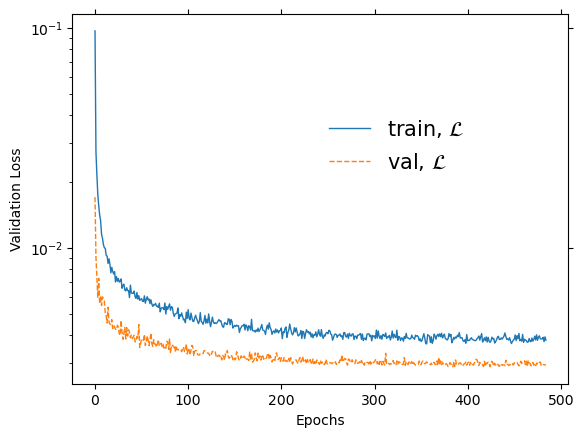

In [33]:
plt.plot(epochs, train_losses, lw=1, label='train, $\mathcal{L}$')
plt.plot(epochs, val_losses, lw=1, linestyle='--', label='val, $\mathcal{L}$')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.tick_params(bottom=True, top=True, left=True, right=True)
plt.legend(fontsize=15, frameon=False, loc=(0.5, 0.55))
plt.yscale('log')  
# plt.savefig('./figures/loss_curve.png', bbox_inches='tight', dpi=250)

## 3. Load model and predict 

### 3.1 Load model

In [54]:
loadpath = './lightning_logs/gnn-4.0-3/version_0/'
gnn_model = XASLightningModule.load_from_checkpoint(glob.glob(loadpath+'checkpoints/*.ckpt')[0])

In [55]:
loadpath = './lightning_logs/mlp-4.0-3/version_0/'
mlp_model = MLPLightningModule.load_from_checkpoint(glob.glob(loadpath+'checkpoints/*.ckpt')[0])

In [57]:
model = XASLightningModule(
    gnn_config=gnn_model.gnn_config,
    head_config=mlp_model.head_config,
    learning_rate=1e-5
)

model.gnn.load_state_dict(gnn_model.gnn.state_dict())
model.spectrum_head.load_state_dict(mlp_model.spectrum_head.state_dict())

<All keys matched successfully>

### 3.2 predict

In [58]:
model = model.to(device)
model.eval()

predictions = []
val_loss = 0.0

with torch.no_grad():   # disables gradient tracking
    for g, _, spectra in val_loader:
        g, spectra = g.to(device), spectra.to(device)
        y_hat = model(g)

        predictions.append(y_hat.cpu())

        loss = torch. nn.MSELoss()(y_hat, spectra)
        val_loss += loss.item() * spectra.size(0)  # sum over batch

# concatenate all predictions into one tensor
predictions = torch.cat(predictions, dim=0)

print(f"Validation loss: {val_loss / len(val_loader.dataset)}")

Validation loss: 0.0028740280372697618


### 3.3. Plot decile curves

In [59]:
performance = []
for ii, data in enumerate(val_dataset): 
    _, _, spectrum = data
    performance.append((nn.MSELoss()(spectrum, predictions[ii]), ii))

In [60]:
performance.sort()

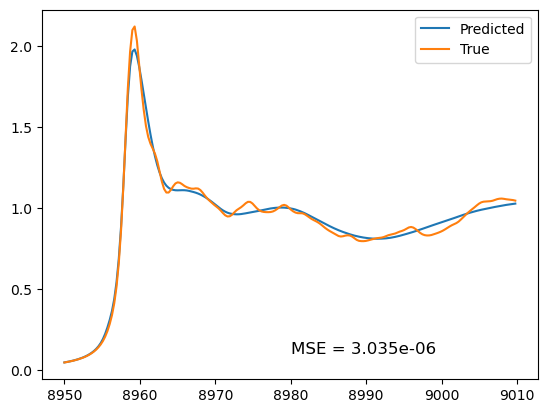

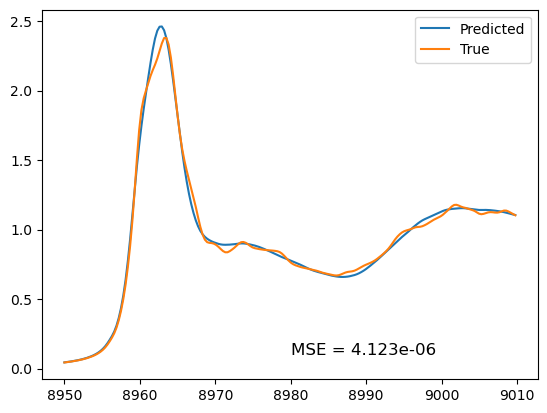

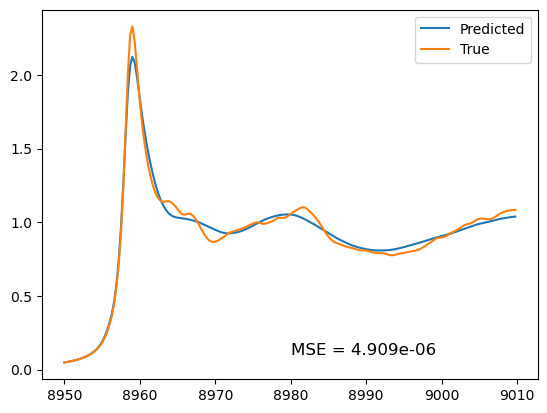

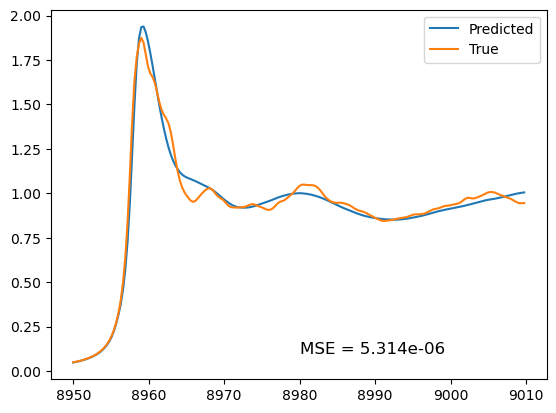

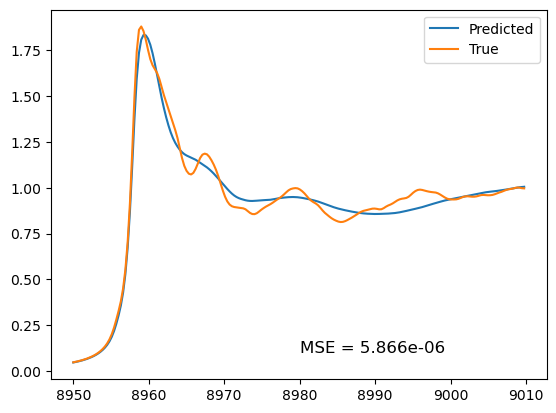

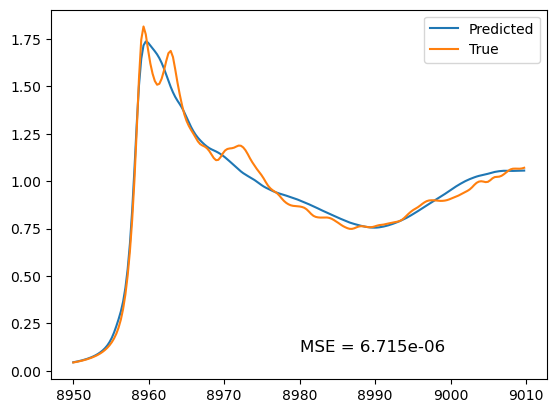

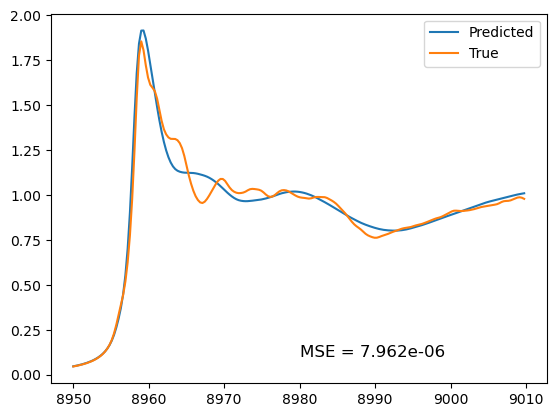

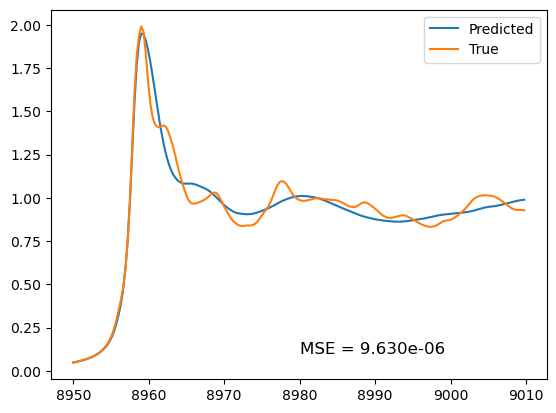

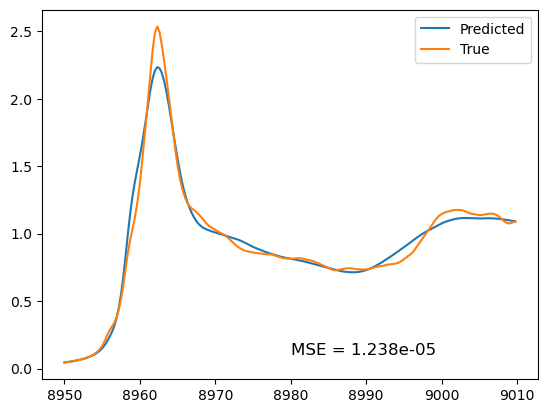

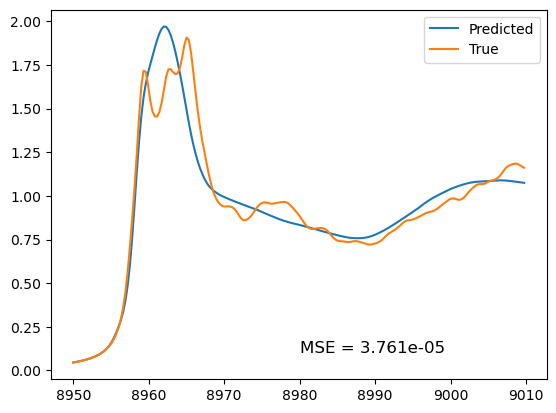

In [61]:
# decimal plot for 10 different XAS 
idx = [i for loss, i in [performance[j] for j in range(20, 201, 20) ]]
for top_i, i in enumerate(idx):
    _, _, sp = val_dataset[i]
    pred = predictions[i]
    loss = nn.MSELoss()(pred/20, sp/20)
    plt.plot(energy_grid, pred.cpu().detach().numpy().flatten(), label='Predicted')
    plt.plot(energy_grid, sp.cpu().numpy().flatten(), label='True')
    plt.annotate(f'MSE = {loss:.3e}', xy=(8980, 0.1), fontsize=12)
    plt.legend()
    plt.show()


## Monitor GPU usage

In [62]:
import gc

In [63]:
torch.cuda.empty_cache()

In [64]:
gc.collect()

29598

In [65]:
torch.cuda.ipc_collect()

In [66]:
print(torch.cuda.memory_allocated() / 1024**3, "GB allocated")
print(torch.cuda.memory_reserved() / 1024**3, "GB reserved")

0.011420249938964844 GB allocated
0.017578125 GB reserved
